# Exercise Solution: Feature Extraction and Plotting

Practice computing features and creating plots to analyze image data.


1. Extract the number of cells from the images and plot cell count as a function of time. Note the images were aqcuired every 30 mins.

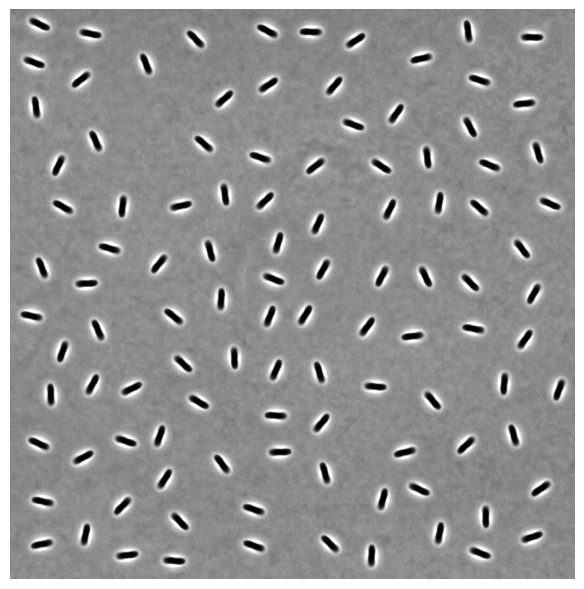

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import glob
from skimage.exposure import rescale_intensity
from skimage.filters import threshold_otsu
from skimage.io import imread
from skimage.measure import label
from iaf.plot import imshow, show_labels, plot_data
from iaf.notebook import init_style
from iaf.process import subtract_background
init_style()

# Path to folder containing images
folder_path = '../_static/image_data/timelapse'

# Search pattern with glob wildcard
pattern = folder_path + '/PhC_position010102_time000*.tif'

# Get sorted list of filenames matching pattern
file_list = sorted(glob.glob(pattern))

# Read all images into a list (as NumPy arrays)
images = [imread(f) for f in file_list]

# Display last frame
p_low, p_high = np.percentile(images[-1], (1, 99))
I = rescale_intensity(images[-1], in_range=(p_low, p_high))

imshow(I)

Threshold = 40
Threshold = 40
Threshold = 32
Threshold = 32
Threshold = 32
Threshold = 32
Threshold = 32


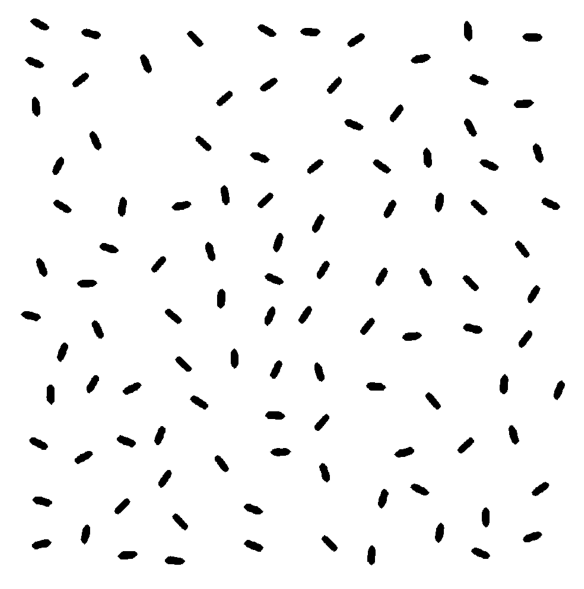

In [121]:
# We first substract the background and then threshold the images to obtain the masks
masks = []
for image in images:


    # Run morphological opening
    background = subtract_background(image, algorithm='rolling_ball', radius = 6,  down_size_factor = 4)

    # Substract background
    I2 = image - background

    # Threshold
    threshold = threshold_otsu(I2)
    print(f"Threshold = {threshold}")
    bw = I2 > threshold - 5 # Fix for noisy first images
    masks.append(bw)

imshow(masks[-1])

Found 1 cells.
Found 3 cells.
Found 7 cells.
Found 16 cells.
Found 35 cells.
Found 64 cells.
Found 107 cells.


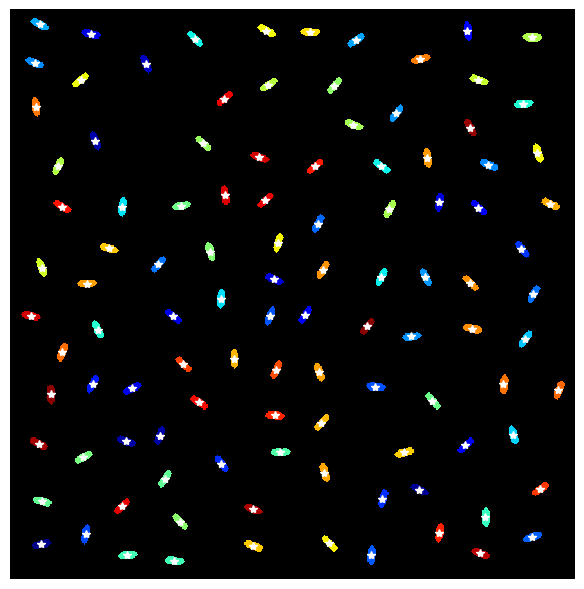

In [122]:
image_interval = 30 # in minutes
labeled_mask = []
time = []
cells = []
for i, mask in enumerate(masks):
    mask_labled, num = label(~mask, background=0, return_num=True, connectivity=1)
    cells.append(num)
    labeled_mask.append(mask_labled)
    time.append(i * image_interval)
    print(f"Found {num} cells.")

show_labels(labeled_mask[-1], plot_centroids=True)

In [123]:
# Create a dataframe and save results
data = {'time' : time, 'ncells': cells}
df = pd.DataFrame(data)
df.to_csv('ncells.csv', index=False)
df.head()

,time,ncells
0,0,1
1,30,3
2,60,7
3,90,16
4,120,35


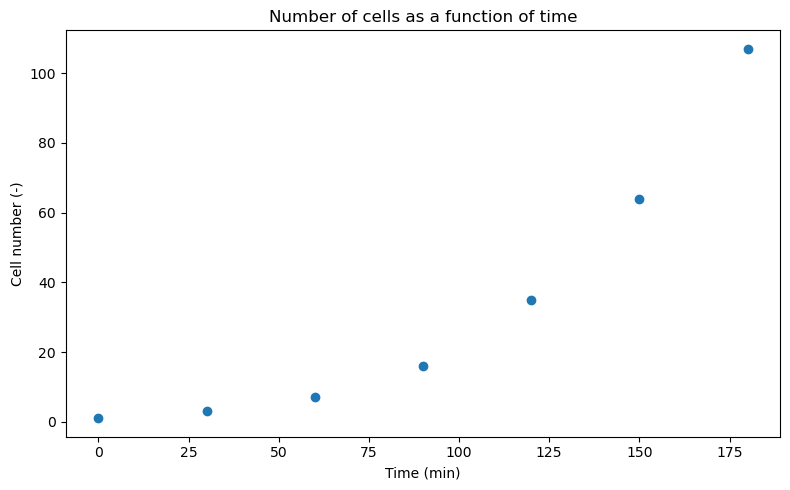

In [124]:
plt.figure(figsize=(8, 5))
plt.scatter(df['time'], df['ncells'])

plt.xlabel("Time (min)")
plt.ylabel("Cell number (-)")
plt.title("Number of cells as a function of time")
plt.show()

2. Fit an appropriate model to determine the time at which there were half the cells from the population given by the last image frame.

In [ ]:
# Define model
def exponential_model(x, a, b, c):
    """Exponential model y_hat = a * exp(b * x) + c."""
    y_hat = a * np.exp(b * x) + c
    return y_hat

# # Define starting values
x = df['time']
y = df['ncells']
start = (y[0], 0.1, 1)
popt, _ = scipy.optimize.curve_fit(exponential_model, x, y, p0 = start)

a = popt[0]
b = popt[1]
c = popt[2]

y_hat = exponential_model(x, popt[0], popt[1], popt[2])
sse = calc_sse(y, y_hat)

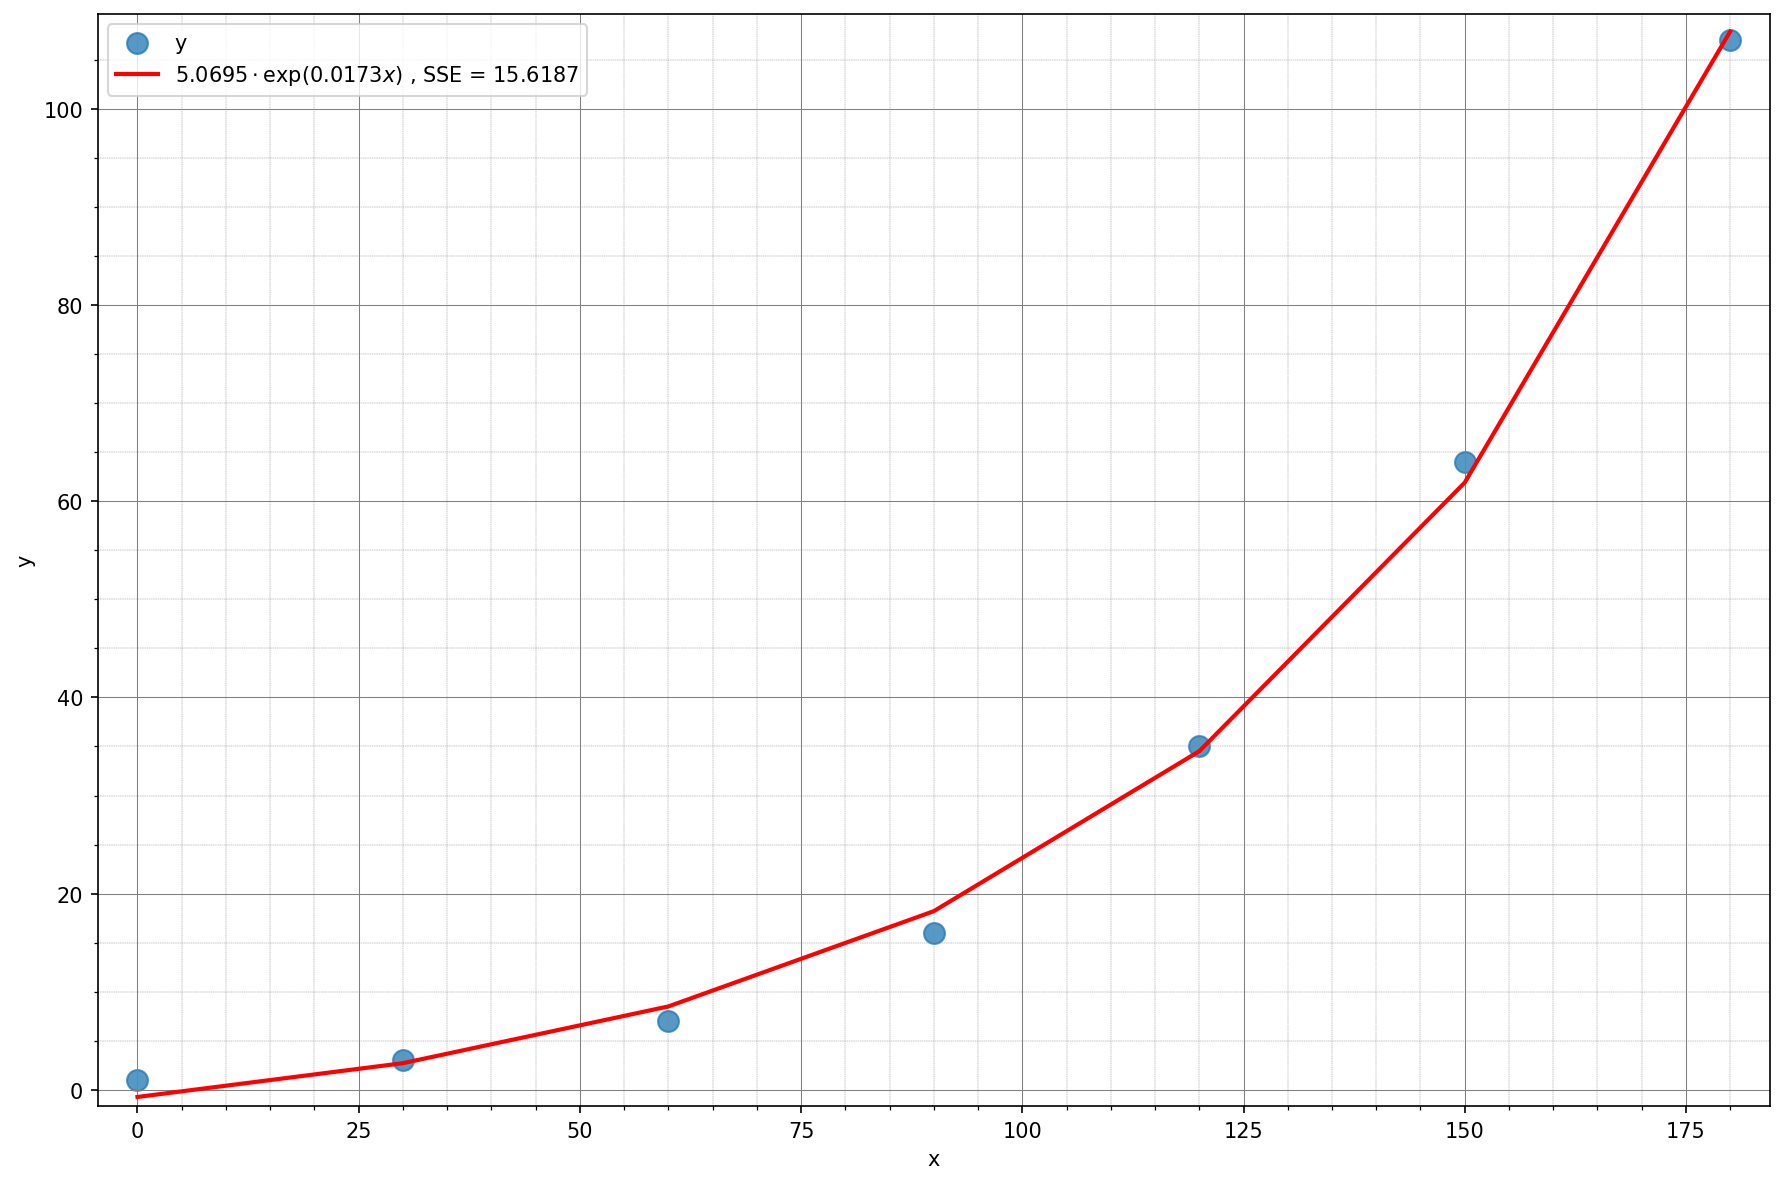

In [148]:
_ = plot_data(x, y, y_hat=y_hat, a=a, b=b, sse=sse, model_for_legend="exp")

Step 1: Maximum population at time $(x_{\max})$

$
y_{\max} = \lim_{x \to x_{\max}} a e^{b x} + c = a e^{b x_{\max}} + c
$

Step 2: Find time $x$ when population reaches fraction $f$ of maximum:

$
y = f \cdot y_{\max}
$

Substitute the model:

$
a e^{b x} + c = f \left( a e^{b x_{\max}} + c \right)
$

Rearranged:

$
a e^{b x} = f a e^{b x_{\max}} + f c - c
$

Divide by $a$:

$
e^{b x} = f e^{b x_{\max}} + \frac{c (f - 1)}{a}
$

Taking natural logarithm:

$
b x = \ln \left( f e^{b x_{\max}} + \frac{c (f - 1)}{a} \right)
$

Solve for $x$:

$
x = \frac{1}{b} \ln \left( f e^{b x_{\max}} + \frac{c (f - 1)}{a} \right)
$


In [152]:
def ec_fraction_time(a, b, c, x_max, f):
    # Compute time when the model reaches fraction f of max at x_max
    term = f * np.exp(b * x_max) + (c * (f - 1)) / a
    if term <= 0:
        raise ValueError("Invalid parameters or fraction leading to negative/zero log input.")
    time = (1 / b) * np.log(term)
    return time

# Parameters from your model fit
x_max = np.max(df['time'])  # maximum time measured

# Compute EC50 and EC75 times
ec50_time = ec_fraction_time(a, b, c, x_max, f=0.5)
ec75_time = ec_fraction_time(a, b, c, x_max, f=0.75)

print(f"EC50 (half max) time: {ec50_time:.2f} mins")
print(f"EC75 (3/4 max) time: {ec75_time:.2f} mins")

EC50 (half max) time: 142.76 mins
EC75 (3/4 max) time: 164.32 mins
